# Customer Churn Prediction

**Goal:** Predict which telecom customers are about to churn, and explain *why* —
not just a score, but a model a retention team could actually act on.

**Dataset:** [IBM Telco Customer Churn](https://github.com/IBM/telco-customer-churn-on-icp4d) —
7,043 real telecom customers, 20 features (contract type, services, tenure, charges), binary churn label.

**Approach:**
1. Clean & explore churn drivers
2. Build a preprocessing + modeling pipeline (Logistic Regression, Random Forest, XGBoost)
3. Evaluate with ROC-AUC / PR-AUC (churn is imbalanced — accuracy alone is misleading)
4. Explain the best model with SHAP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score, precision_recall_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier
import shap
import os

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
CHART_DIR = "../assets"
os.makedirs(CHART_DIR, exist_ok=True)

## 1. Load & clean

In [2]:
df = pd.read_csv("../data/telco_churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# TotalCharges is stored as string with blanks for brand-new customers (tenure=0) — coerce to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(f"Rows with missing TotalCharges: {df['TotalCharges'].isna().sum()} (all tenure=0 new customers)")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

df = df.drop(columns=["customerID"])
df["Churn"] = (df["Churn"] == "Yes").astype(int)

churn_rate = df["Churn"].mean()
print(f"Overall churn rate: {churn_rate:.1%}")

Rows with missing TotalCharges: 11 (all tenure=0 new customers)
Overall churn rate: 26.5%


## 2. Churn drivers (EDA)

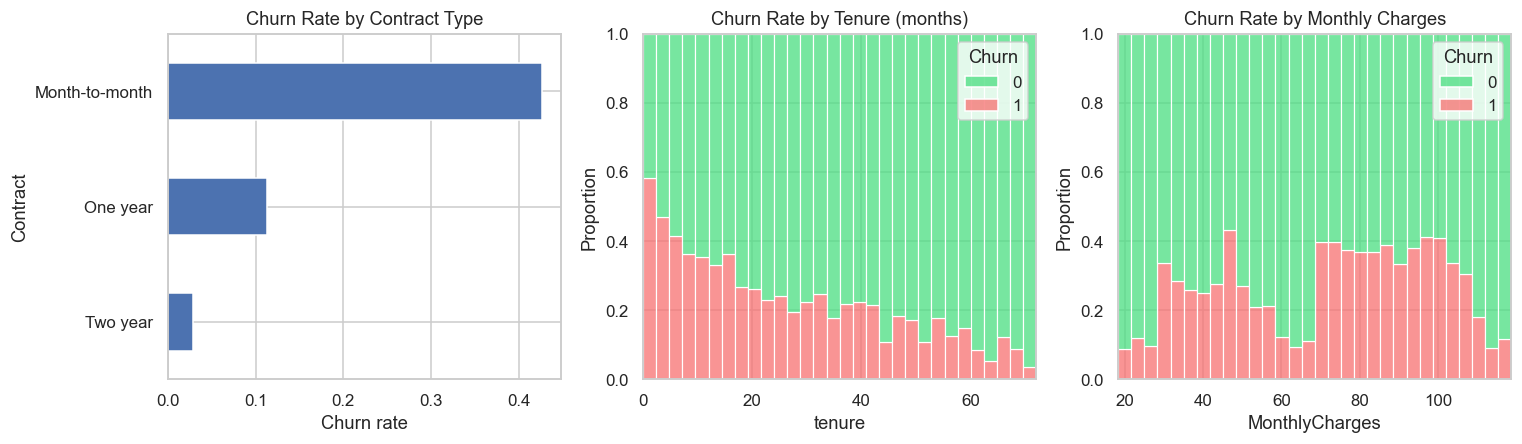

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

contract_churn = df.groupby("Contract")["Churn"].mean().sort_values()
contract_churn.plot(kind="barh", ax=axes[0], color=sns.color_palette("deep")[0])
axes[0].set_title("Churn Rate by Contract Type")
axes[0].set_xlabel("Churn rate")

sns.histplot(data=df, x="tenure", hue="Churn", bins=30, multiple="fill", ax=axes[1],
             palette=["#4ade80", "#f87171"])
axes[1].set_title("Churn Rate by Tenure (months)")
axes[1].set_ylabel("Proportion")

sns.histplot(data=df, x="MonthlyCharges", hue="Churn", bins=30, multiple="fill", ax=axes[2],
             palette=["#4ade80", "#f87171"])
axes[2].set_title("Churn Rate by Monthly Charges")
axes[2].set_ylabel("Proportion")

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/churn_drivers.png", dpi=150)
plt.show()

Month-to-month contracts, low tenure, and high monthly charges all associate with
much higher churn — consistent with "customers who haven't committed yet are the
ones who leave."

## 3. Preprocessing + model pipeline

In [5]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(exclude="object").columns.tolist()
print(f"{len(categorical_cols)} categorical, {len(numeric_cols)} numeric features")

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_cols),
    ("num", StandardScaler(), numeric_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | Train churn rate: {y_train.mean():.1%}")

15 categorical, 4 numeric features
Train: 5634 | Test: 1409 | Train churn rate: 26.5%


In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(), eval_metric="logloss", random_state=42,
    ),
}

results = {}
fitted_pipelines = {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    preds = pipe.predict(X_test)
    results[name] = {
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba),
        "proba": proba,
        "preds": preds,
    }
    fitted_pipelines[name] = pipe

pd.DataFrame({k: {"ROC-AUC": v["roc_auc"], "PR-AUC": v["pr_auc"]} for k, v in results.items()}).T.round(4)

,ROC-AUC,PR-AUC
Logistic Regression,0.8417,0.6328
Random Forest,0.8425,0.6531
XGBoost,0.8411,0.6516


## 4. Model comparison

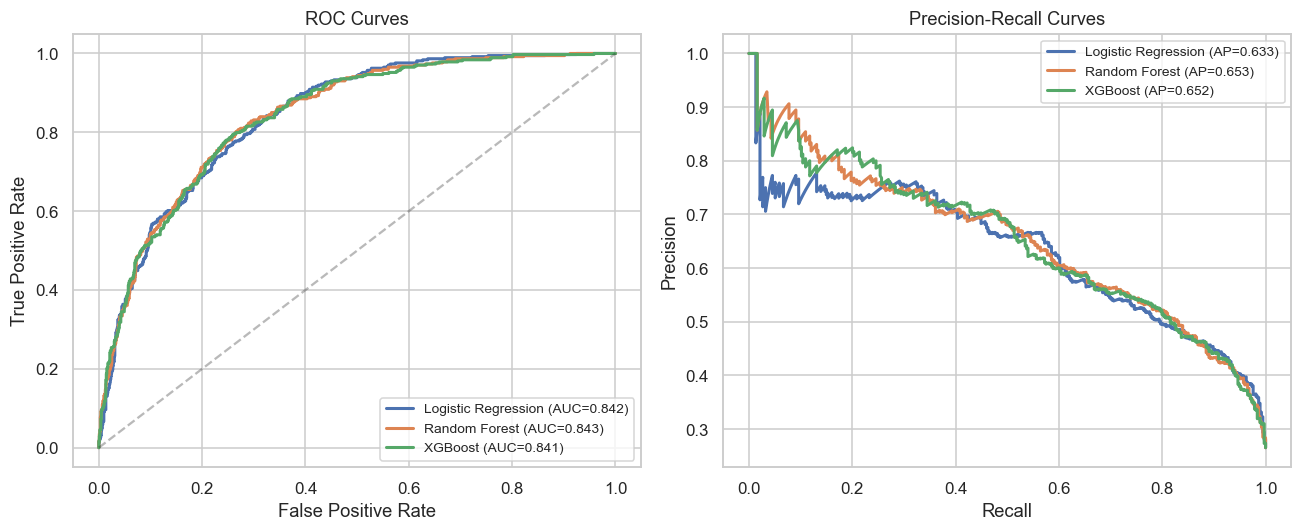

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["proba"])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})", linewidth=2)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves")
axes[0].legend(fontsize=9)

for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res["proba"])
    axes[1].plot(rec, prec, label=f"{name} (AP={res['pr_auc']:.3f})", linewidth=2)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/model_comparison.png", dpi=150)
plt.show()

In [8]:
best_name = max(results, key=lambda k: results[k]["roc_auc"])
print(f"Best model by ROC-AUC: {best_name}")
print(classification_report(y_test, results[best_name]["preds"], target_names=["Stayed", "Churned"]))

Best model by ROC-AUC: Random Forest
              precision    recall  f1-score   support

      Stayed       0.90      0.76      0.82      1035
     Churned       0.53      0.76      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



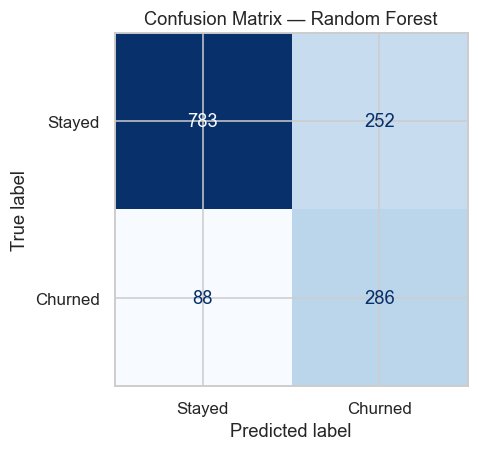

In [9]:
cm = confusion_matrix(y_test, results[best_name]["preds"])
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Churned"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/confusion_matrix.png", dpi=150)
plt.show()

## 5. Explainability (SHAP)

A ROC-AUC score doesn't tell a retention team what to *do*. SHAP breaks down exactly
which features push predictions toward "churn" — globally, and for individual customers.

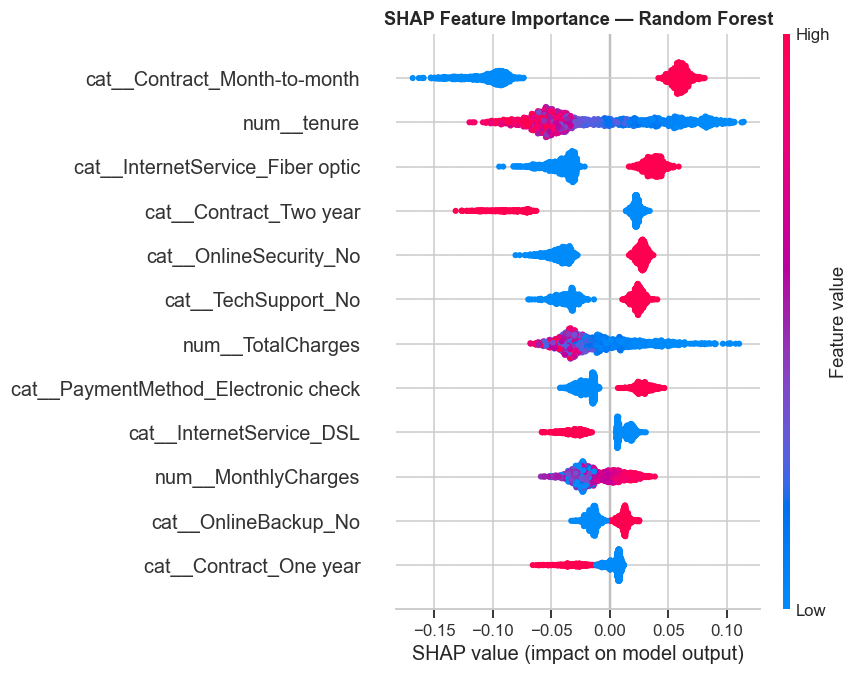

In [10]:
best_pipe = fitted_pipelines[best_name]
X_test_transformed = best_pipe.named_steps["prep"].transform(X_test)
feature_names = best_pipe.named_steps["prep"].get_feature_names_out()
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

explainer = shap.TreeExplainer(best_pipe.named_steps["model"])
shap_values = explainer.shap_values(X_test_df)

# For binary classifiers, shap_values comes back as (n_samples, n_features, n_classes)
# (or a [class0, class1] list in older shap versions) — select the "Churned" class
if isinstance(shap_values, list):
    shap_values_churn = shap_values[1]
elif np.ndim(shap_values) == 3:
    shap_values_churn = shap_values[:, :, 1]
else:
    shap_values_churn = shap_values

fig = plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values_churn, X_test_df, show=False, max_display=12)
plt.title(f"SHAP Feature Importance — {best_name}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. What would reduce churn

- **Contract type dominates**: month-to-month customers churn far more than 1-2 year
  contract customers — pushing month-to-month customers toward annual contracts
  (via a discount or incentive) is the single highest-leverage lever available.
- **Tenure matters most in the first year**: churn risk is highest for customers who
  haven't hit the ~12-month mark yet — an onboarding/engagement push in months 1-6
  would target the riskiest window directly.
- **High monthly charges without add-on services** (no tech support / online security)
  is a recurring churn pattern — bundling support services may improve perceived value
  enough to offset price sensitivity.